In [1]:
# import library
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict

c:\Users\pumas\AppData\Local\Programs\Python\Python313\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
load_dotenv(override=True)

True

In [4]:
class State(TypedDict):
    topic:str
    outline:str
    blog:str

In [5]:
model = ChatGroq(model="openai/gpt-oss-20b")

def outline_generator(old_state:State) ->State:
    prompt = "You are a Proffesional Editor with 15+ years of experience. You give the outline of the topic given to you. That outline will be used to write a blog."
    prompt += f"Today's topic:\n {old_state['topic']}"
    response = model.invoke(prompt)

    old_state['outline'] = response.content
    return old_state

def blog_writter(old_state:State) ->State:
    prompt = "You are a Proffesional Blog writter with 10+ years experience of writing blogs. You write a good blog based on the topic and outline given to you."
    prompt += f"Today's topic:\n {old_state['topic']}\n"
    prompt += f"Outline for this topic:\n {old_state['outline']}"
    response = model.invoke(prompt)

    old_state['blog'] = response.content
    return old_state

In [6]:
graph = StateGraph(State)
graph.add_node("outline_generator",outline_generator)
graph.add_node("blog_writter",blog_writter)
graph.add_edge(START, "outline_generator")
graph.add_edge("outline_generator","blog_writter")
graph.add_edge("blog_writter",END)

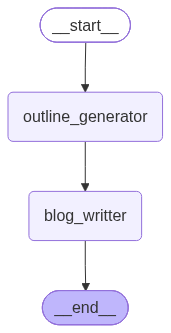

In [7]:
workflow = graph.compile()
workflow

In [ ]:
# initial_state = {'topic':"Challenges in Data Analysis"}
# response = workflow.invoke(initial_state)
print(response["blog"])

# Challenges in Data Analysis  
*By [Your Name] – 10+ Years of Turning Numbers into Insight*

---

## I. Introduction  

> **“In 2018, the U.S. Census Bureau discovered that 30 % of the data it published was corrupted by a single line of code.”**  
> — *Data Quality Quarterly*  

A single line of code, a mislabeled column, a missing value—any of these can send an entire analysis astray. In an era where decisions are increasingly data‑driven, understanding the hurdles that lie between raw data and actionable insight is no longer a luxury; it’s a necessity.

**Why it matters**  
- **Businesses** risk costly mis‑strategies if their models are built on flawed data.  
- **Researchers** can unknowingly publish invalid results, eroding trust in science.  
- **Policymakers** may enact ineffective or even harmful regulations if their evidence base is shaky.  

**What you’ll find in this post**  
- The core data quality pitfalls that derail analyses.  
- The classic “3 Vs” (plus a 4th) that defi